# 1. Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2. Load data 100 file citra yang sudah ada di google drive anda

In [4]:
import os

folder_path = '/content/drive/MyDrive/Computer Vision/UTS Comvis/DatasetPepperBell'

os.chdir(folder_path)

for file_name in os.listdir(folder_path):
    print(f"Nama File: {file_name}")

Nama File: 00f2e69a-1e56-412d-8a79-fdce794a17e4___JR_B.Spot 3132.JPG
Nama File: 0bd0f439-013b-40ed-a6d1-4e67e971d437___JR_B.Spot 3272.JPG
Nama File: 0d2635e7-df23-4ceb-b3ba-3af50bb58357___NREC_B.Spot 1874.JPG
Nama File: 0c6f6805-490e-438c-b9cd-3fd7ee29f31b___NREC_B.Spot 9123.JPG
Nama File: 0ce74db6-be9b-4c43-a104-6a3f9bcd2de2___NREC_B.Spot 1827.JPG
Nama File: 0c4e75b2-e4aa-437e-815c-636271d66bec___JR_B.Spot 3244.JPG
Nama File: 0b27c03f-b3bc-4d96-9b76-6fbd779404b9___NREC_B.Spot 1799.JPG
Nama File: 0a9cfb27-280e-475a-bbb4-8eeaeff38b8c___NREC_B.Spot 9177.JPG
Nama File: 0c2392f6-3e69-4baf-b9f3-197623f6631a___JR_B.Spot 3176.JPG
Nama File: 0d524d59-fb02-481b-9034-64f1de0da914___NREC_B.Spot 9060.JPG
Nama File: 04d46cfb-9cc8-4083-82af-ca2bb57c8182___NREC_B.Spot 1814.JPG
Nama File: 0c99cb45-b4e0-4ade-bba5-fab3b678f0bb___JR_B.Spot 8912.JPG
Nama File: 0a4c007d-41ab-4659-99cb-8a4ae4d07a55___NREC_B.Spot 1954.JPG
Nama File: 0b47ce18-7cfe-45e8-b21e-b83cb6282455___JR_B.Spot 3162.JPG
Nama File: 0c1eb1f

# 3. Melakukan ekstraksi fitur pada 100 citra

In [18]:
import cv2                  # Library untuk pengolahan citra
import os                   # Untuk membaca file dalam folder
import numpy as np          # Untuk operasi numerik
import pandas as pd         # Untuk membuat tabel (DataFrame)

# Path folder dataset citra daun
folder_path = '/content/drive/MyDrive/Computer Vision/UTS Comvis/DatasetPepperBell'

# List untuk menyimpan fitur warna dari tiap citra
features = []

# List untuk menyimpan nama file citra
image_names = []

# Loop untuk membaca semua file dalam folder
for filename in os.listdir(folder_path):

    # Membaca gambar menggunakan OpenCV
    img = cv2.imread(os.path.join(folder_path, filename))

    # Jika gambar gagal dibaca, skip
    if img is None:
        continue

    # Resize gambar agar semua ukuran sama (biar konsisten)
    img = cv2.resize(img, (300, 300))

    # ================= RGB =================
    # OpenCV membaca dalam format BGR, jadi perlu dipisah
    B, G, R = cv2.split(img)

    # Menghitung rata-rata setiap channel warna
    mean_r = np.mean(R)   # Rata-rata merah
    mean_g = np.mean(G)   # Rata-rata hijau
    mean_b = np.mean(B)   # Rata-rata biru

    # ================= HSV =================
    # Konversi dari BGR ke HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Pisahkan channel HSV
    H, S, V = cv2.split(hsv)

    # Hitung rata-rata HSV
    mean_h = np.mean(H)   # Hue (jenis warna)
    mean_s = np.mean(S)   # Saturation (kejenuhan warna)
    mean_v = np.mean(V)   # Value (kecerahan)

    # Simpan semua fitur ke dalam list
    features.append([mean_r, mean_g, mean_b, mean_h, mean_s, mean_v])

    # Simpan nama file
    image_names.append(filename)

# Membuat DataFrame (tabel) dari hasil ekstraksi
df = pd.DataFrame(features, columns=['R', 'G', 'B', 'H', 'S', 'V'])

# Menambahkan kolom nama file di depan
df.insert(0, 'Image', image_names)

# Menampilkan hasil ekstraksi
print(df)

                                                 Image           R  \
0    00f2e69a-1e56-412d-8a79-fdce794a17e4___JR_B.Sp...  128.734122   
1    0bd0f439-013b-40ed-a6d1-4e67e971d437___JR_B.Sp...  131.841822   
2    0d2635e7-df23-4ceb-b3ba-3af50bb58357___NREC_B....  106.361400   
3    0c6f6805-490e-438c-b9cd-3fd7ee29f31b___NREC_B....  110.134533   
4    0ce74db6-be9b-4c43-a104-6a3f9bcd2de2___NREC_B....  112.297544   
..                                                 ...         ...   
100  1bf8d046-2b1c-44bf-9a00-9f16e0971d2a___JR_HL 8...  107.372178   
101  1c159479-4972-41d3-a6ff-fbdb648d72c2___JR_HL 7...  123.280733   
102  1d6e01ff-affd-4867-895d-fb82b6b0dce3___JR_HL 7...  117.251233   
103  1c043016-2d55-444d-a379-4a2aafc41a32___JR_HL 7...  123.325544   
104  1d0430f7-af9b-4e3d-9d4a-47cf676556fe___JR_HL 5...  171.506067   

              G           B           H           S           V  
0    132.981444  125.417133   93.276400   51.054411  141.427689  
1    138.149256  101.580333

# 4. Melakukan penampungan nilai-nilai fitur ke dalam file .xlsx atau .csv

In [19]:
import cv2
import os
import numpy as np
import pandas as pd

# Path folder citra daun
folder_path = '/content/drive/MyDrive/Computer Vision/UTS Comvis/DatasetPepperBell'

features = []
image_names = []

for filename in os.listdir(folder_path):

    img = cv2.imread(os.path.join(folder_path, filename))
    if img is None:
        continue

    img = cv2.resize(img, (300, 300))

    # ===== RGB =====
    B, G, R = cv2.split(img)
    mean_r = np.mean(R)
    mean_g = np.mean(G)
    mean_b = np.mean(B)

    # ===== HSV =====
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    H, S, V = cv2.split(hsv)
    mean_h = np.mean(H)
    mean_s = np.mean(S)
    mean_v = np.mean(V)

    # Simpan fitur
    features.append([mean_r, mean_g, mean_b, mean_h, mean_s, mean_v])
    image_names.append(filename)

# Buat DataFrame
df = pd.DataFrame(features, columns=['R', 'G', 'B', 'H', 'S', 'V'])
df.insert(0, 'Image', image_names)

# Simpan ke CSV
df.to_csv('fitur_daun.csv', index=False)

print(df)

                                                 Image           R  \
0    00f2e69a-1e56-412d-8a79-fdce794a17e4___JR_B.Sp...  128.734122   
1    0bd0f439-013b-40ed-a6d1-4e67e971d437___JR_B.Sp...  131.841822   
2    0d2635e7-df23-4ceb-b3ba-3af50bb58357___NREC_B....  106.361400   
3    0c6f6805-490e-438c-b9cd-3fd7ee29f31b___NREC_B....  110.134533   
4    0ce74db6-be9b-4c43-a104-6a3f9bcd2de2___NREC_B....  112.297544   
..                                                 ...         ...   
100  1bf8d046-2b1c-44bf-9a00-9f16e0971d2a___JR_HL 8...  107.372178   
101  1c159479-4972-41d3-a6ff-fbdb648d72c2___JR_HL 7...  123.280733   
102  1d6e01ff-affd-4867-895d-fb82b6b0dce3___JR_HL 7...  117.251233   
103  1c043016-2d55-444d-a379-4a2aafc41a32___JR_HL 7...  123.325544   
104  1d0430f7-af9b-4e3d-9d4a-47cf676556fe___JR_HL 5...  171.506067   

              G           B           H           S           V  
0    132.981444  125.417133   93.276400   51.054411  141.427689  
1    138.149256  101.580333

# 5. Klasifikasi KNN

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
#Load Data
data = pd.read_csv('fitur_daun.csv')
data['Label'] = ["Sehat" if g > r else "Tidak Sehat" for r, g in zip(data['R'], data['G'])]
X = data[['R', 'G', 'B', 'H', 'S', 'V']]   # fitur
y = data['Label']                         # target


# 6. Membuat Model KNN

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Membuat model KNN
knn = KNeighborsClassifier(n_neighbors=3)

# Training model
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

# 7. Tampilkan Prediksi dan Evaluasi

In [22]:
# Prediksi
y_pred = knn.predict(X_test)

# Evaluasi
print("Akurasi:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Akurasi: 0.9523809523809523

Confusion Matrix:
 [[17  0]
 [ 1  3]]

Classification Report:
               precision    recall  f1-score   support

       Sehat       0.94      1.00      0.97        17
 Tidak Sehat       1.00      0.75      0.86         4

    accuracy                           0.95        21
   macro avg       0.97      0.88      0.91        21
weighted avg       0.96      0.95      0.95        21



# 8. Menampilkan Confusion Matrix

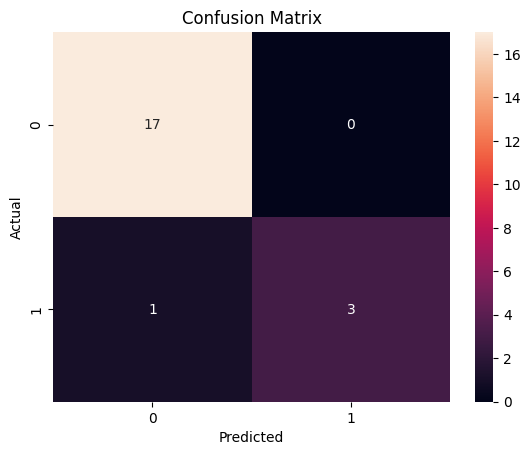

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#9. Membandingkan Nilai K

In [24]:
for k in [3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    print(f"K = {k}, Akurasi = {accuracy_score(y_test, y_pred)}")

K = 3, Akurasi = 0.9523809523809523
K = 5, Akurasi = 0.9523809523809523
K = 7, Akurasi = 0.9047619047619048


# 10. Akurasi vs Nilai K

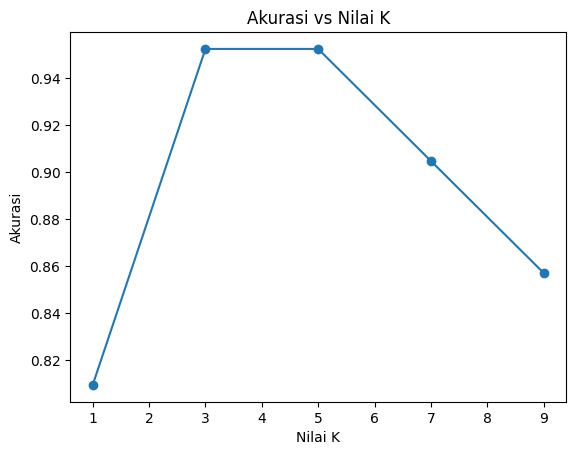

In [25]:
accuracies = []
k_values = [1,3,5,7,9]

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

plt.figure()
plt.plot(k_values, accuracies, marker='o')
plt.title("Akurasi vs Nilai K")
plt.xlabel("Nilai K")
plt.ylabel("Akurasi")
plt.show()

# 11. Distribusi Hasil Klasifikasi (Menampilkan Pie Chart Hasil Klasifikasi)

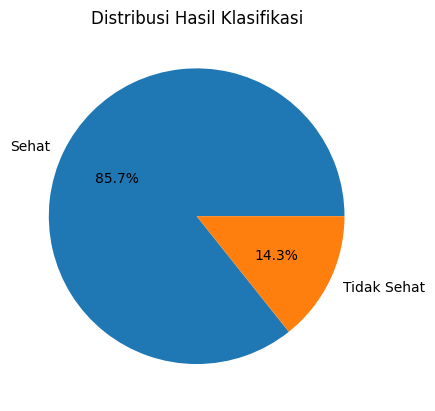

Label
Sehat          92
Tidak Sehat    13
Name: count, dtype: int64


In [31]:
counts = pd.Series(y_pred).value_counts()

plt.figure()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("Distribusi Hasil Klasifikasi")
plt.show()
print(data['Label'].value_counts())